### 차트 작성 시 한글 깨짐 방지를 위한 koreanize-matplotlib 설치

In [1]:
!pip install koreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 15.5 MB/s eta 0:00:00


### 라이브러리 import

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

### 1. 데이터 로드 및 분할

In [10]:
pima_columns = ['pregnancies', 'glucose', 'blood_pressure', 'skin_thickness', 'insulin', 'bmi', 'diabetes_pedigree_function', 'age', 'outcome']
pima_data_url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'
df = pd.read_csv(pima_data_url, names=pima_columns)

In [11]:
# Feature(X)와 Target(y) 분리
X = df.drop('outcome', axis=1)
y = df['outcome']

# 학습용/테스트용 데이터 분할 (8:2)
# stratify=y: 타겟 클래스 비율 유지 (강의자료 강조 사항)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"학습 데이터: {X_train.shape}")
print(f"테스트 데이터: {X_test.shape}")

학습 데이터: (614, 8)
테스트 데이터: (154, 8)


### 2. 모델 학습(DecisionTree)

In [14]:
# max_depth=4: 트리의 최대 깊이 제한 (과적합 방지)
# min_samples_leaf=10: 리프 노드가 되기 위한 최소 샘플 수
dt_clf = DecisionTreeClassifier(
    criterion='gini',       # 분할 기준: 지니 지수 (Page 4)
    max_depth=4,            # 사전 가지치기: 최대 깊이
    min_samples_leaf=10,    # 사전 가지치기: 리프 노드 최소 샘플
    random_state=42
)

# 모델 학습
dt_clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, min_samples_leaf=10, random_state=42)

### 3. Tree 시각화

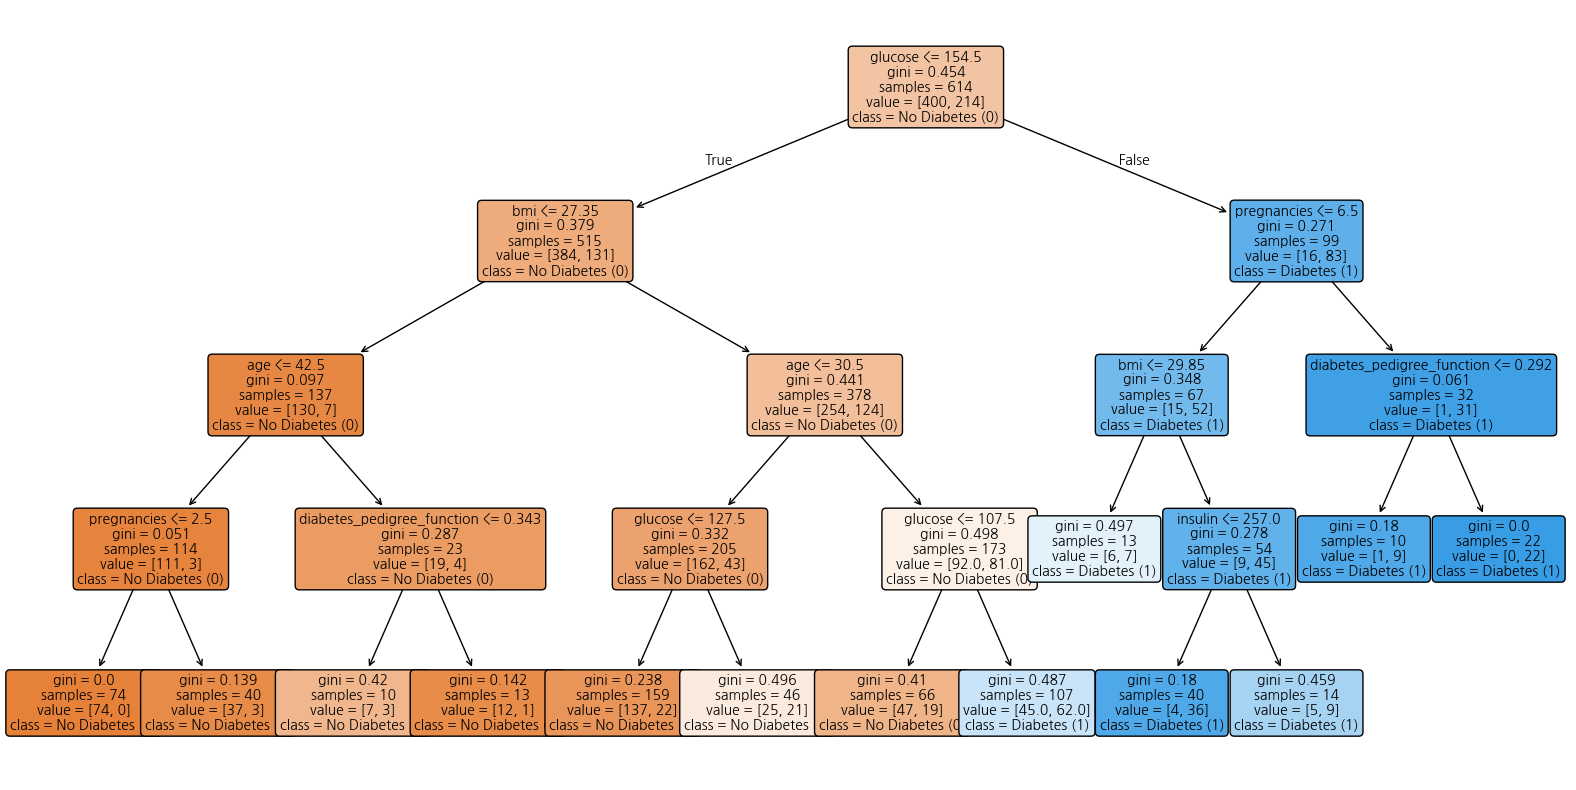

In [18]:
plt.figure(figsize=(20, 10))
plot_tree(
    dt_clf,
    feature_names=X.columns,
    class_names=['No Diabetes (0)', 'Diabetes (1)'],
    filled=True,        # 노드 색칠 (불순도에 따라 색상 진하기 변경)
    rounded=True,       # 노드 모서리 둥글게
    fontsize=10
)
plt.show()

### 4. 모델 성능 평가

In [19]:
# 테스트 데이터 예측
y_pred = dt_clf.predict(X_test)

# 정확도(Accuracy) 출력
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy (정확도): {accuracy:.4f}")

# 상세 리포트 출력 (Precision, Recall, F1-score)
print("\n[Classification Report]")
print(classification_report(y_test, y_pred, target_names=['No Diabetes (0)', 'Diabetes (1)']))

Accuracy (정확도): 0.7987

[Classification Report]
                 precision    recall  f1-score   support

No Diabetes (0)       0.83      0.87      0.85       100
   Diabetes (1)       0.73      0.67      0.70        54

       accuracy                           0.80       154
      macro avg       0.78      0.77      0.77       154
   weighted avg       0.80      0.80      0.80       154



In [20]:
# Feature Importance 확인
for name, value in zip(X.columns, dt_clf.feature_importances_):
    print(f"{name}: {value:.4f}")

pregnancies: 0.0180
glucose: 0.6718
blood_pressure: 0.0000
skin_thickness: 0.0000
insulin: 0.0130
bmi: 0.1636
diabetes_pedigree_function: 0.0066
age: 0.1268


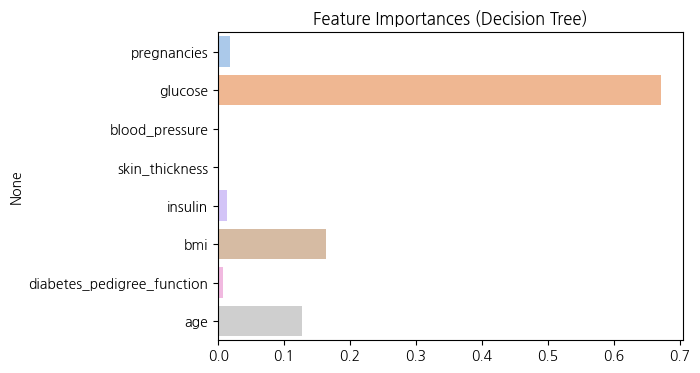

In [23]:
# 특성 중요도 시각화
plt.figure(figsize=(6, 4))
sns.barplot(x=dt_clf.feature_importances_, y=X.columns, palette='pastel')
plt.title('Feature Importances (Decision Tree)')
plt.show()